<a href="https://colab.research.google.com/github/rybak97/free_courses/blob/main/OCR_in_Python_With_Pytesseract.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Based on: https://www.datacamp.com/tutorial/optical-character-recognition-ocr-in-python-with-pytesseract

In [20]:
import cv2
!pip install pytesseract
!sudo apt-get update
!sudo apt-get install poppler-utils

!pip install pdf2image

import pytesseract

import requests
import numpy as np
from google.colab.patches import cv2_imshow
from pytesseract import Output
from pdf2image import convert_from_bytes

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
0 upgraded, 0 newly install

## Simple example w/ pytesseract

In [21]:
image_url = 'https://github.com/anvaldes/AI_ML_Lab/blob/d752768c674b2bf169eb09b8796f5b80514e2a97/09.Deep_Learning_AI_I/42.OCR_Pytesseract/images/easy_text.png?raw=true'

# Download the image
response = requests.get(image_url)
image_array = np.asarray(bytearray(response.content), dtype=np.uint8)

# Read the image using cv2.imdecode
image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

In [22]:
# Convert to text
text = pytesseract.image_to_string(image)
print(text)

This text is
easy to extract.



## Drawing bounding boxes around text

In [23]:
data = pytesseract.image_to_data(image, output_type=Output.DICT)
n_boxes = len(data["text"])

In [24]:
data

{'level': [1, 2, 3, 4, 5, 5, 5, 4, 5, 5, 5],
 'page_num': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 'block_num': [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 'par_num': [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 'line_num': [0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2],
 'word_num': [0, 0, 0, 0, 1, 2, 3, 0, 1, 2, 3],
 'left': [0, 20, 20, 114, 114, 354, 599, 20, 20, 258, 406],
 'top': [0, 33, 33, 33, 33, 38, 33, 137, 149, 137, 137],
 'width': [800, 748, 748, 569, 183, 185, 84, 748, 184, 88, 362],
 'height': [226, 178, 178, 62, 62, 57, 62, 74, 62, 56, 56],
 'conf': [-1, -1, -1, -1, 95, 95, 95, -1, 96, 96, 96],
 'text': ['', '', '', '', 'This', 'text', 'is', '', 'easy', 'to', 'extract.']}

In [25]:
image_with_boxes = image.copy()

for i in range(n_boxes):
   if data["conf"][i] == -1:
       continue
   # Coordinates
   x, y = data["left"][i], data["top"][i]
   w, h = data["width"][i], data["height"][i]

   # Corners
   top_left = (x, y)
   bottom_right = (x + w, y + h)

   # Box params
   green = (0, 255, 0)
   thickness = 2  # pixels

   cv2.rectangle(
       img=image_with_boxes, pt1=top_left, pt2=bottom_right, color=green, thickness=thickness
   )

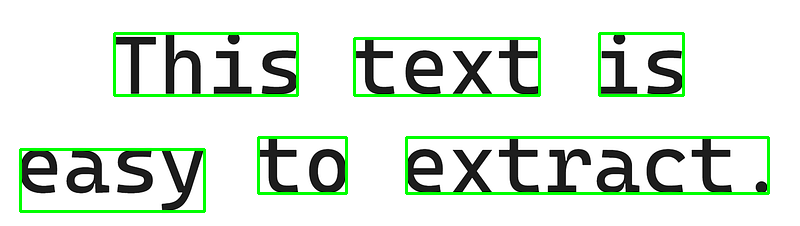

In [26]:
# Display the image with bounding boxes
cv2_imshow(image_with_boxes)

## Real example: OCR on .pdf

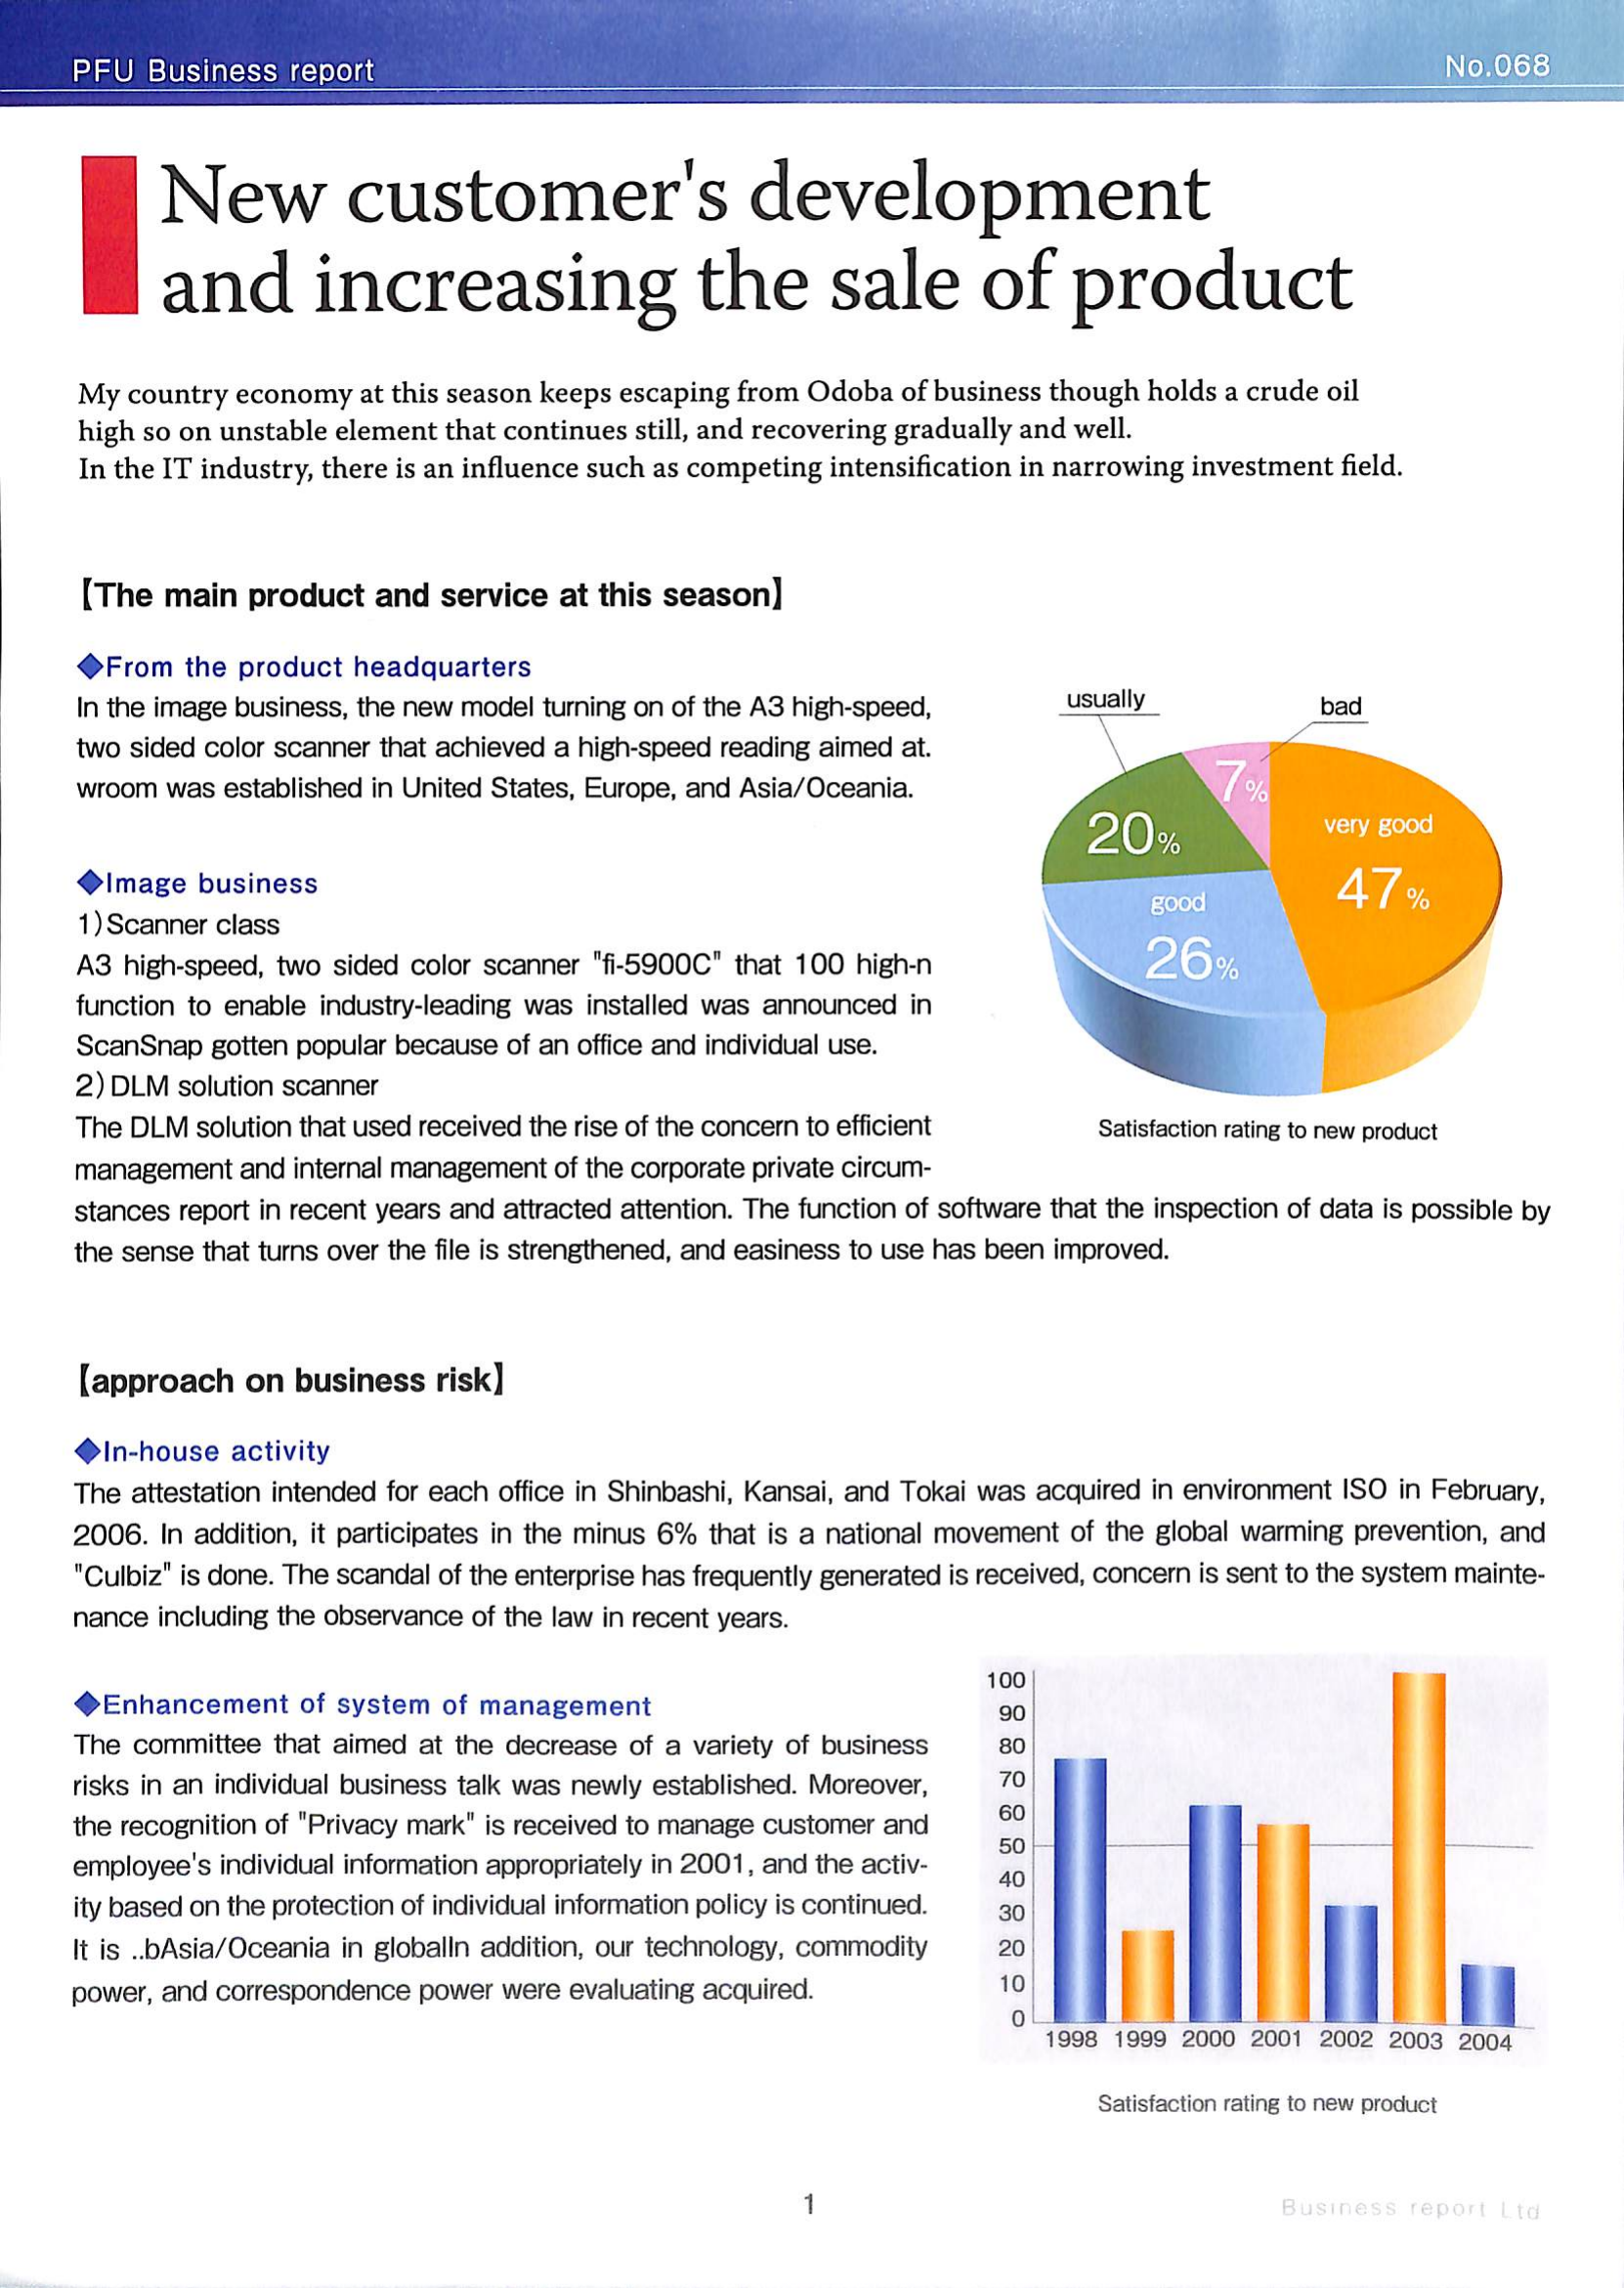

In [27]:
pdf_url = 'https://github.com/BexTuychiev/medium_stories/blob/master/2024/4_april/6_ocr/scanned_document.pdf?raw=true'

# Download the PDF file
response = requests.get(pdf_url)
pdf_bytes = response.content

# Convert PDF to a list of images (each page is an image)
# This returns PIL Image objects, which need to be converted to OpenCV format (numpy array)
images_from_pdf = convert_from_bytes(pdf_bytes)

# Convert the first PIL Image to an OpenCV image (numpy array)
if images_from_pdf:
    # PIL images are RGB, OpenCV uses BGR by default, so we convert.
    first_image_cv = cv2.cvtColor(np.array(images_from_pdf[0]), cv2.COLOR_RGB2BGR)
    cv2_imshow(first_image_cv)
else:
    print("No pages found in the PDF.")

In [28]:
# Convert to text
text = pytesseract.image_to_string(first_image_cv)
print(text[:377])

PEU Business report

 

New customer's development
and increasing the sale of product

My country economy at this season keeps escaping from Odoba of business though holds a crude oil
high so on unstable element that continues still, and recovering gradually and well.
In the IT industry, there is an influence such as competing intensification in narrowing investment field.




In [29]:
raw_pdf = pytesseract.image_to_pdf_or_hocr(first_image_cv)

In [30]:
# Save the OCR'd PDF data to a file
ocr_pdf_path = 'ocr_output.pdf'
with open(ocr_pdf_path, 'wb') as f:
    f.write(raw_pdf)

print(f'OCR output saved to: {ocr_pdf_path}')

OCR output saved to: ocr_output.pdf
